In [1]:
#Instalar librerias
!pip install dtreeviz
!pip install catboost
!pip install shap
!pip install xgboost
!pip install optbinning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.9/213.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 54.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 19.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.13.0 requires protobuf<7

In [35]:
#Importo librerias necesarias para el proceso de EDA (Esploratory Data Analysis)
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import folium
import numpy as np
from datetime import datetime
import plotly.express as px
import plotly.graph_objects as go

#Importo librerias necesarias para el proceso de Feature engineering y evaluación de modelos
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import GridSearchCV

#Importo librerias necesarias para ML
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from catboost import CatBoostClassifier
import shap
from sklearn.tree import export_graphviz
import graphviz
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)





In [36]:
# Descargar los datos con pandas
df_red = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv',sep=';')

df_white = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv',sep=';')

df = pd.concat([df_red, df_white])

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [37]:
#No queremos incluir la variable quality dentro del tratamiento de outliers
df_outliers = df.drop(columns='quality')
df_target= df['quality']



Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

for col in df_outliers.columns:
    col_outliers = ((df_outliers[col] < (Q1[col] - 3 * IQR[col])) | (df_outliers[col] > (Q3[col] + 3 * IQR[col]))) # se detectan outliers usando el rango interquartil
    df_outliers.loc[col_outliers, col] = df_outliers[col].median() #Los reemplzamos con la mediana

df_target_b= df['quality'].apply(lambda x: 1 if x >= 7 else 0)

#Juntamos el dataset limpio con el nuevo target
df_limpio = df_outliers.copy()
df_limpio['quality'] = df_target_b
df_limpio.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [38]:
# División de datos en entrenamiento y test
X = df_limpio.drop(['quality'], axis=1)
y = df_limpio['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) #Usaremos division 80-20 por la cantidad de datos, lo usual en datasets más grandes es 70-30


In [ ]:

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento del modelo
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

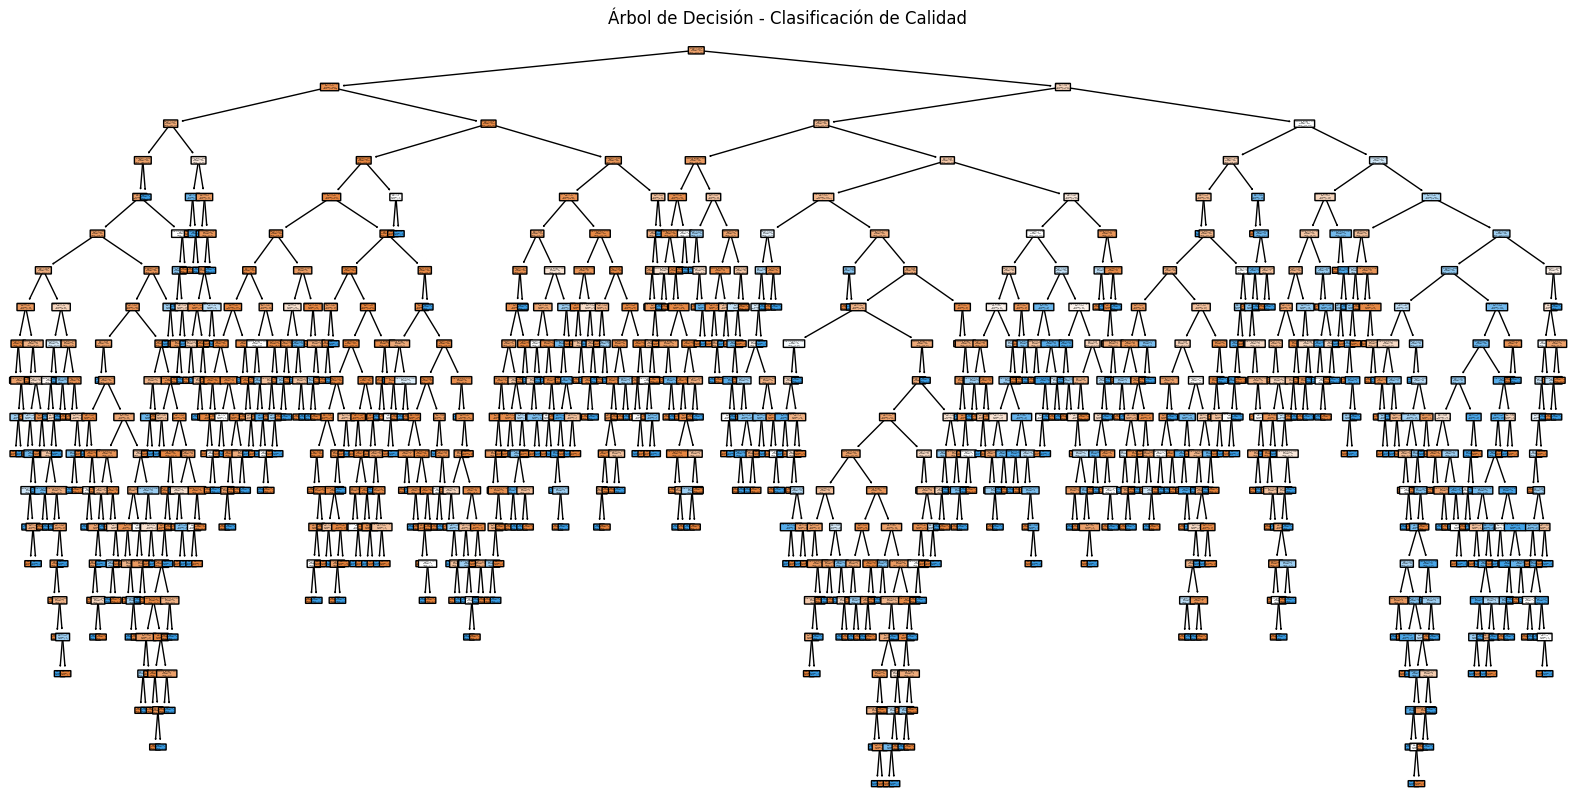

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol, feature_names=X.columns, class_names=[str(c) for c in sorted(y.unique())], filled=True, rounded=True)
plt.title("Árbol de Decisión - Clasificación de Calidad")
plt.show()


In [ ]:
dot_data = export_graphviz(
    modelo_arbol,
    out_file=None,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("arbol_decision", format="png", cleanup=True)
graph.view()



'arbol_decision.pdf'

In [ ]:
y_pred = modelo_arbol.predict(X_test)
y_proba = modelo_arbol.predict_proba(X_test)


In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89      1048
           1       0.56      0.62      0.59       252

    accuracy                           0.83      1300
   macro avg       0.73      0.75      0.74      1300
weighted avg       0.84      0.83      0.83      1300



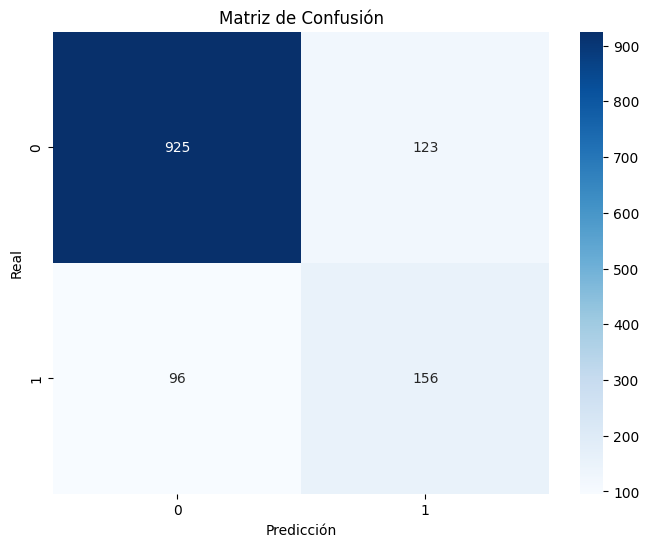

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()


In [ ]:
#curva ROC
y_probs = modelo_arbol.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()




Podar árbol - control de hiperparametros

In [ ]:
# Modelo con hiperparámetros ajustados
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,              # Limita la profundidad del árbol
    min_samples_split=10,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=5,       # Mínimo de muestras en una hoja
    random_state=42
)

# Entrenamiento
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

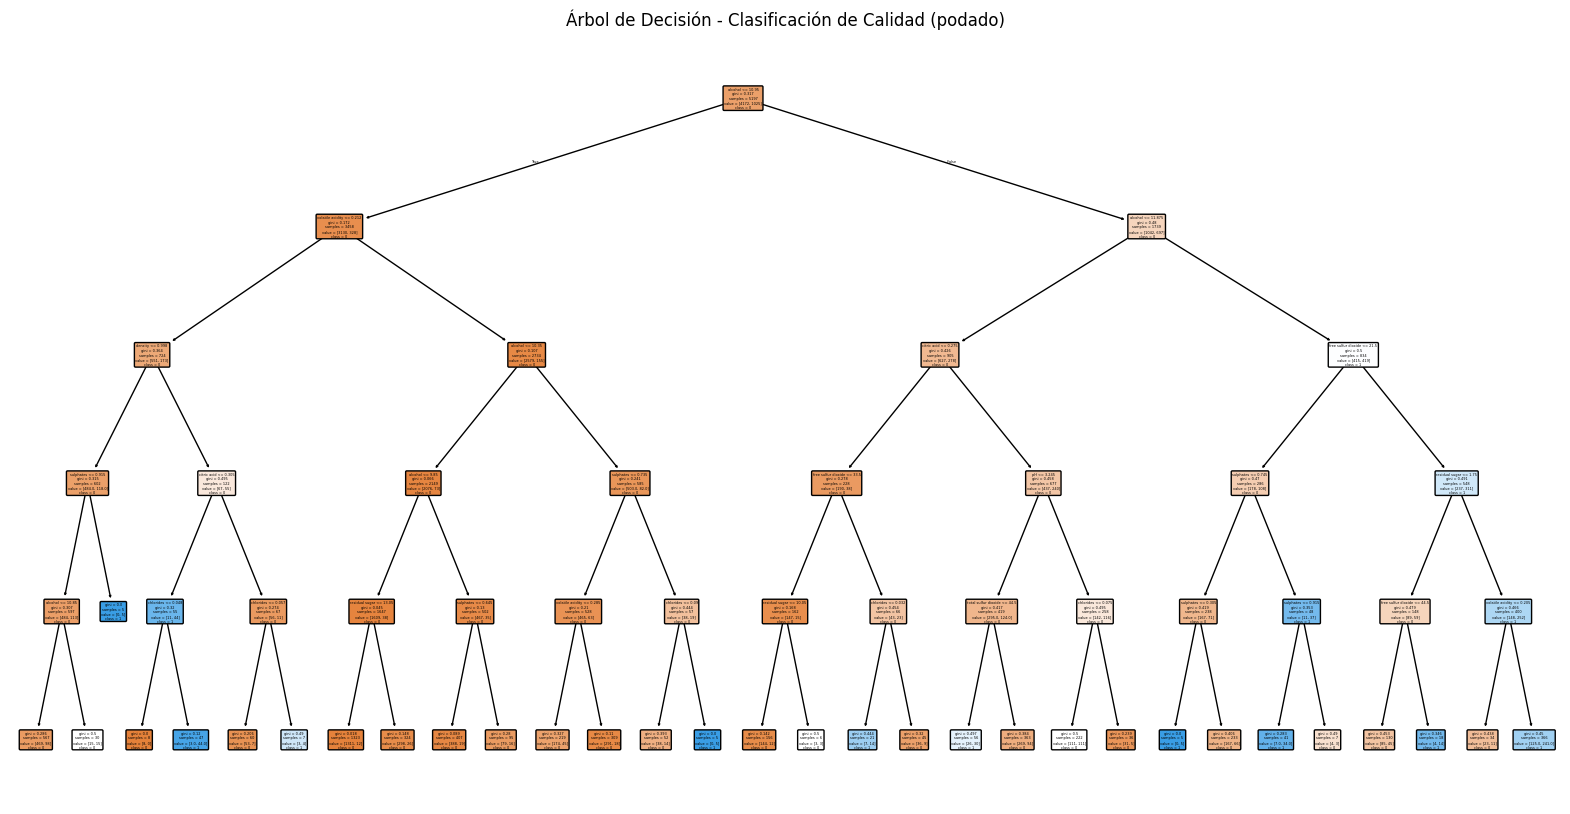

In [ ]:
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol, feature_names=X.columns, class_names=[str(c) for c in sorted(y.unique())], filled=True, rounded=True)
plt.title("Árbol de Decisión - Clasificación de Calidad (podado)")
plt.show()

In [ ]:
dot_data = export_graphviz(
    modelo_arbol,
    out_file=None,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("arbol_decision_podado", format="png", cleanup=True)
graph.view()

'arbol_decision_podado.pdf'

In [ ]:
y_pred = modelo_arbol.predict(X_test)
y_proba = modelo_arbol.predict_proba(X_test)

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1048
           1       0.63      0.34      0.44       252

    accuracy                           0.83      1300
   macro avg       0.74      0.65      0.67      1300
weighted avg       0.81      0.83      0.81      1300



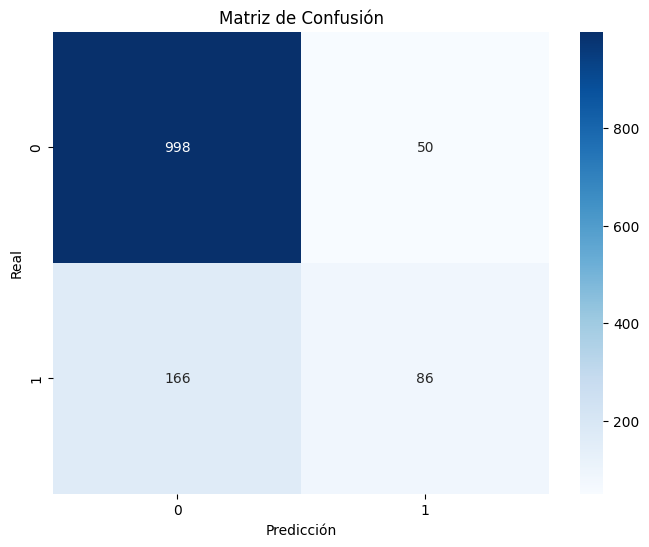

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
#curva ROC
y_probs = modelo_arbol.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


In [ ]:
# Definimos el árbol base
modelo_base = DecisionTreeClassifier(random_state=42)

# Definimos el grid de hiperparámetros
param_grid = {
    'max_depth': [3, 5, 7, 10, 20, None],
    'min_samples_split': [2, 5, 10, 50],
    'min_samples_leaf': [1, 5, 10, 20]
}

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5,                      # Validación cruzada con 5 folds
    scoring='precision',        # Métrica de evaluación
    n_jobs=-1,                 # Usa todos los núcleos disponibles
    verbose=1
)

# Ejecutamos la búsqueda
grid_search.fit(X_train, y_train)


Fitting 5 folds for each of 96 candidates, totalling 480 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, 20, None],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 50]},
             scoring='precision', verbose=1)

In [ ]:
# Mejor combinación de hiperparámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Mejor score en validación cruzada
print("Mejor precisión en CV:", grid_search.best_score_)

# Modelo final entrenado con los mejores parámetros
modelo_optimo = grid_search.best_estimator_


Mejores parámetros encontrados:
{'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Mejor precisión en CV: 0.6340565742408691


In [ ]:
# Modelo con hiperparámetros ajustados
modelo_arbol = DecisionTreeClassifier(
    max_depth=5,              # Limita la profundidad del árbol
    min_samples_split=2,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=5,       # Mínimo de muestras en una hoja
    random_state=42
)

# Entrenamiento
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, random_state=42)

In [ ]:
y_pred = modelo_arbol.predict(X_test)
y_proba = modelo_arbol.predict_proba(X_test)

In [ ]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      1048
           1       0.63      0.34      0.44       252

    accuracy                           0.83      1300
   macro avg       0.74      0.65      0.67      1300
weighted avg       0.81      0.83      0.81      1300



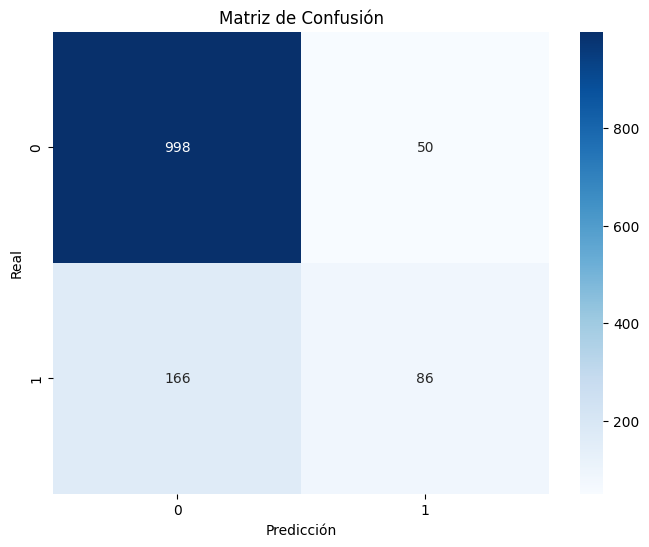

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test,y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [ ]:
#curva ROC
y_probs = modelo_arbol.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()

Tarea: ajustar un random forest pero con parametros optimizados

Aplicación a nuestro problema de vacunas

In [3]:
# obtener desde GitHub
url_flu_codificado = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_filtrado_codificado.csv"
url_flu_test = "https://raw.githubusercontent.com/jesustristan17/Curso-Machine-Learning/refs/heads/main/datasets/Flu%20Shot%20Learning/flu_test_final_codificado.csv"

# Carga los datos
flu_codificado = pd.read_csv(url_flu_codificado)
print(flu_codificado.head())

flu_test = pd.read_csv(url_flu_test)
print(flu_test.head())


   opinion_seas_vacc_effective  opinion_seas_risk  doctor_recc_seasonal  \
0                          2.0                1.0                   0.0   
1                          4.0                2.0                   0.0   
2                          4.0                1.0                   0.0   
3                          5.0                4.0                   1.0   
4                          3.0                1.0                   0.0   

   age_group  opinion_h1n1_risk  opinion_h1n1_vacc_effective  \
0          3                1.0                          3.0   
1          1                4.0                          5.0   
2          0                1.0                          3.0   
3          4                3.0                          3.0   
4          2                3.0                          3.0   

   employment_industry  doctor_recc_h1n1  employment_occupation  \
0                   11               0.0                     11   
1                   13        

In [4]:
# Cargar dataset limpio
X = flu_codificado.drop(columns='seasonal_vaccine')
y = flu_codificado['seasonal_vaccine']

# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)


In [6]:
# Definimos el árbol base
modelo_base = DecisionTreeClassifier(random_state=42)

# Definimos el grid de hiperparámetros
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 5, 10,20]
}

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=modelo_base,
    param_grid=param_grid,
    cv=5,                      # Validación cruzada con 5 folds
    scoring='accuracy',        # Métrica de evaluación
    n_jobs=-1,                 # Usa todos los núcleos disponibles
    verbose=1
)

# Ejecutamos la búsqueda
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 5, 10, 20],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy', verbose=1)

In [7]:
# Mejor combinación de hiperparámetros
print("Mejores parámetros encontrados:")
print(grid_search.best_params_)

# Mejor score en validación cruzada
print("Mejor precisión en CV:", grid_search.best_score_)

# Modelo final entrenado con los mejores parámetros
modelo_optimo = grid_search.best_estimator_


Mejores parámetros encontrados:
{'max_depth': 7, 'min_samples_leaf': 10, 'min_samples_split': 2}
Mejor precisión en CV: 0.7619471097589515


In [9]:
#Usamos el modelo de gridseacrh
grid_search.fit(X_train, y_train)

#Ajuste del modelo
y_pred = grid_search.predict(X_test)
y_proba = grid_search.predict_proba(X_test)

Fitting 5 folds for each of 80 candidates, totalling 400 fits


In [11]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      2855
           1       0.75      0.74      0.74      2487

    accuracy                           0.76      5342
   macro avg       0.76      0.76      0.76      5342
weighted avg       0.76      0.76      0.76      5342



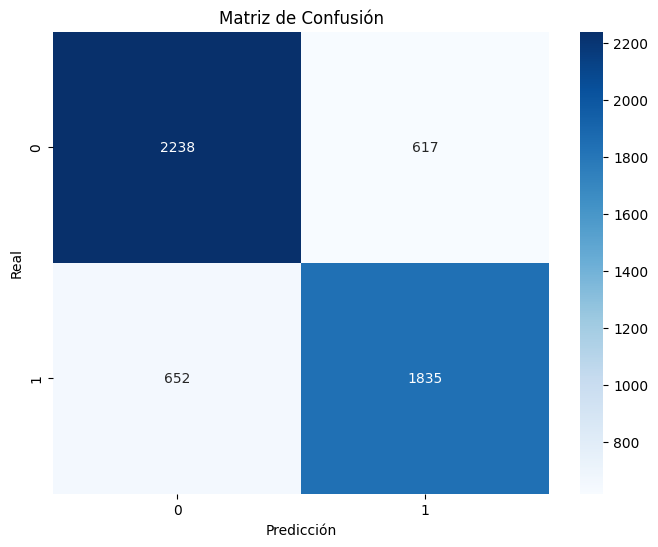

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [14]:
#curva ROC
y_probs = grid_search.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


In [15]:
# Modelo con hiperparámetros ajustados
modelo_arbol = DecisionTreeClassifier(
    max_depth=7,              # Limita la profundidad del árbol
    min_samples_split=10,     # Mínimo de muestras para dividir un nodo
    min_samples_leaf=2,       # Mínimo de muestras en una hoja
    random_state=42
)

# 1. Entrenamiento
modelo_arbol.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=7, min_samples_leaf=2, min_samples_split=10,
                       random_state=42)

In [16]:
#2. Ajuste del modelo
y_pred = modelo_arbol.predict(X_test)
y_proba = modelo_arbol.predict_proba(X_test)

In [17]:
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred))


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.77      0.78      0.78      2855
           1       0.75      0.74      0.74      2487

    accuracy                           0.76      5342
   macro avg       0.76      0.76      0.76      5342
weighted avg       0.76      0.76      0.76      5342



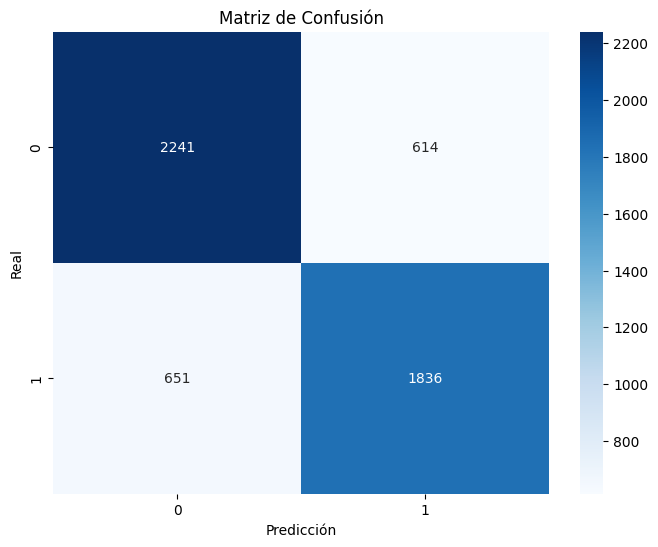

In [18]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

In [19]:
#curva ROC
y_probs = modelo_arbol.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


In [20]:
dot_data = export_graphviz(
    modelo_arbol,
    out_file=None,
    feature_names=X.columns,
    class_names=[str(c) for c in sorted(y.unique())],
    filled=True,
    rounded=True,
    special_characters=True
)

graph = graphviz.Source(dot_data)
graph.render("arbol_flu", format="png", cleanup=True)
graph.view()

'arbol_flu.pdf'

**Random Forrest classifier**

In [21]:
#Modelo
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf.fit(X_train, y_train)
y_pred = model_rf.predict(X_test)


In [22]:
# Reporte de clasificación
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.73      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



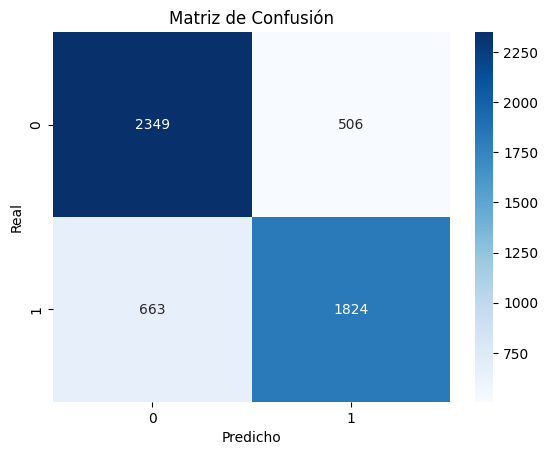

In [23]:
# Matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

In [24]:
#curva ROC
y_probs = model_rf.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva (seasonal vaccine)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()



In [25]:
# Definimos el modelo base
rf = RandomForestClassifier(random_state=42)

# Definimos el espacio de búsqueda
param_grid = {
    'n_estimators': [100, 250, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

# Configuramos GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,  # Validación cruzada con 5 folds
    scoring='accuracy',
    n_jobs=-1,  # Usa todos los núcleos disponibles
    verbose=1
)

# Entrenamos con los datos
grid_search.fit(X_train, y_train)

# Resultados
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score:", grid_search.best_score_)


Fitting 5 folds for each of 36 candidates, totalling 180 fits


KeyboardInterrupt: 

In [26]:
from sklearn.ensemble import RandomForestClassifier

# Modelo con hiperparámetros ajustados
modelo_rf_optimo = RandomForestClassifier(
    n_estimators=250,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Entrenamiento
modelo_rf_optimo.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=250, random_state=42)

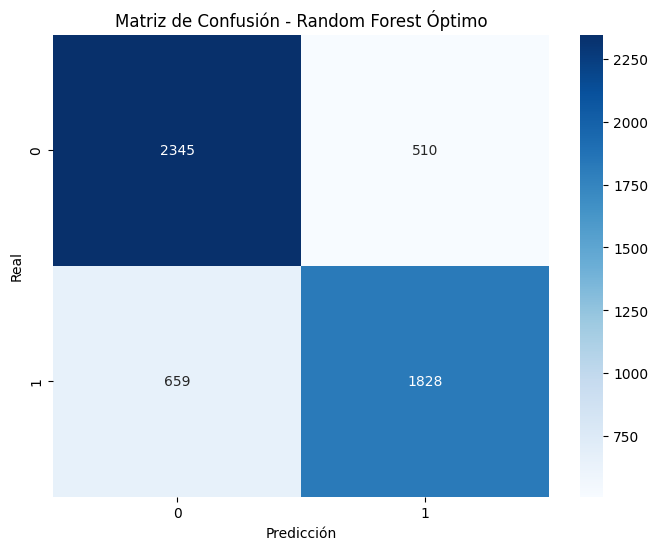

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      2855
           1       0.78      0.74      0.76      2487

    accuracy                           0.78      5342
   macro avg       0.78      0.78      0.78      5342
weighted avg       0.78      0.78      0.78      5342



In [27]:
# Predicciones
y_pred_rf = modelo_rf_optimo.predict(X_test)

# Matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - Random Forest Óptimo")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

# Reporte de clasificación
print("Reporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))


In [28]:
#curva ROC
y_probs = modelo_rf_optimo.predict_proba(X_test)[:, 1]  # Probabilidades para la clase positiva (seasonal vaccine)

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc_score = roc_auc_score(y_test, y_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name='ROC', line=dict(color='royalblue')))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='no_model', line=dict(dash='dash')))
fig.update_layout(title=f'Curva ROC - AUC: {auc_score:.3f}',
                  xaxis_title='Tasa de Falsos Positivos (FPR)',
                  yaxis_title='Tasa de Verdaderos Positivos (TPR)',
                  width=700, height=500)
fig.show()


Feature importance

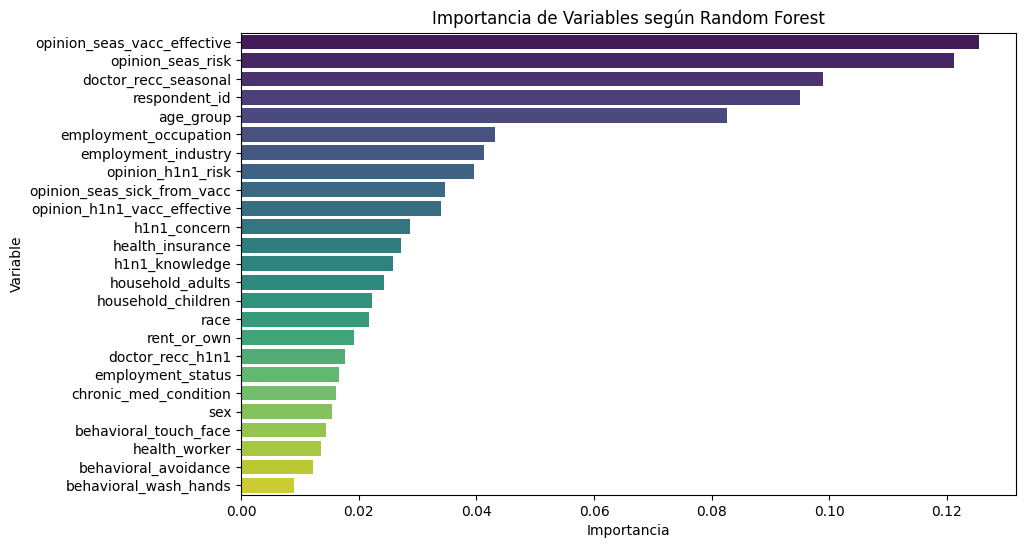

In [29]:
importancias = modelo_rf_optimo.feature_importances_
df_importancia = pd.DataFrame({'Variable': X.columns, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=df_importancia, x='Importancia', y='Variable', palette='viridis')
plt.title("Importancia de Variables según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()


In [30]:
importancias

array([0.12550501, 0.12124215, 0.09901515, 0.08258999, 0.03961618,
       0.03402868, 0.04130231, 0.0176417 , 0.0430794 , 0.02715855,
       0.01610036, 0.02862728, 0.01663986, 0.01354069, 0.02577831,
       0.02227027, 0.01450617, 0.0089108 , 0.01916032, 0.02178793,
       0.03462964, 0.01538163, 0.01217742, 0.02430886, 0.09500136])

In [31]:
df_importancia

,Variable,Importancia
0,opinion_seas_vacc_effective,0.125505
1,opinion_seas_risk,0.121242
2,doctor_recc_seasonal,0.099015
24,respondent_id,0.095001
3,age_group,0.082590
8,employment_occupation,0.043079
6,employment_industry,0.041302
4,opinion_h1n1_risk,0.039616
20,opinion_seas_sick_from_vacc,0.034630
5,opinion_h1n1_vacc_effective,0.034029


**Archivo probabilidades arbol de decisión**

In [32]:
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
import pandas as pd

# Entrenar el modelo
modelo_arbol = DecisionTreeClassifier(
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=2,
    random_state=42
)

modelo_arbol.fit(X_train, y_train)

# Obtener las probabilidades de la clase positiva
probs = modelo_arbol.predict_proba(flu_test[X_train.columns])[:, 1]

# Agregar la columna de score redondeado
flu_test = flu_test.copy()
flu_test['predicted_score'] = probs.round(3)

# Seleccionar columnas relevantes
pred_flu = flu_test[['respondent_id', 'predicted_score']].sort_values(by='predicted_score', ascending=False)

# Generar nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"decision_tree_output_{timestamp}.csv"

# Exportar a CSV
pred_flu.to_csv(file_name, index=False)

# Mostrar resultados
display(pred_flu)


,respondent_id,predicted_score
26601,53308,1.0
26437,53144,1.0
26403,53110,1.0
17647,44354,1.0
17788,44495,1.0
...,...,...
4987,31694,0.0
16364,43071,0.0
16333,43040,0.0
24233,50940,0.0


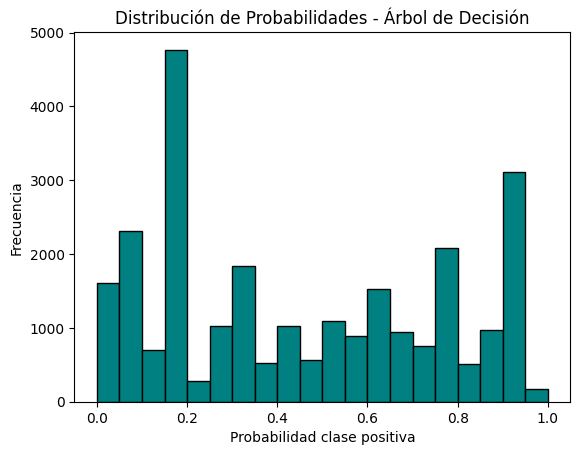

In [33]:
import matplotlib.pyplot as plt

flu_test['predicted_score'] = modelo_arbol.predict_proba(flu_test[X_train.columns])[:, 1]
plt.hist(flu_test['predicted_score'], bins=20, color='teal', edgecolor='black')
plt.title("Distribución de Probabilidades - Árbol de Decisión")
plt.xlabel("Probabilidad clase positiva")
plt.ylabel("Frecuencia")
plt.show()


In [34]:
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime
import pandas as pd

modelo_rf_optimo = RandomForestClassifier(
    n_estimators=250,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42
)

# Entrenamiento
modelo_rf_optimo.fit(X_train, y_train)

flu_test = flu_test.drop(columns=['predicted_score'], errors='ignore')


assert set(X_train.columns).issubset(flu_test.columns), "flu_test debe contener las mismas variables que X_train"

# Obtener las probabilidades de la clase positiva
probs = modelo_rf_optimo.predict_proba(flu_test[X_train.columns])[:, 1]

# Agregar la columna de score redondeado
flu_test = flu_test.copy()
flu_test['predicted_score'] = probs.round(3)

# Seleccionar columnas relevantes
pred_flu = flu_test[['respondent_id', 'predicted_score']].sort_values(by='predicted_score', ascending=False)

# Generar nombre de archivo con timestamp
timestamp = datetime.now().strftime("%Y-%m-%d_%H-%M")
file_name = f"rf_output_{timestamp}.csv"

# Exportar a CSV
pred_flu.to_csv(file_name, index=False)

# Mostrar resultados
display(pred_flu)

,respondent_id,predicted_score
25015,51722,0.971
10917,37624,0.968
7297,34004,0.967
6539,33246,0.963
18384,45091,0.962
...,...,...
26576,53283,0.049
14518,41225,0.048
21155,47862,0.047
21277,47984,0.046
